用遗传算法求解函数 \
f(x)= x+10sin(5 x)+7cos(4 x) \
的最大值。其中x的取值范围为[0,10],这是一个有多个局部极值的函数。

思路：将x编码为[0, 10]，能表示10-6小数的二进制字符串

In [75]:
from GA import *

In [76]:
np.log2(10 * (10 ** 6))   # 24位二进制串

np.float64(23.253496664211536)

In [77]:
class GA_func(GA):
    """遗传算法求解函数"""
    def __init__(self, pop_size=50, max_generations=100, cross_rate=0.8, mutation_rate=0.1):
        # 调用父类的初始化方法（复用父类超参数）
        super().__init__(pop_size, max_generations, cross_rate, mutation_rate)
        # 子类可覆盖父类的问题参数（如调整二进制长度）
        self.dim = 24      # 种群每个个体是24位二进制串

        # 个体的形式和实际解的形式有差异
        self.x_dim = 1     # 变量维度
        self.x_min = 0     # 变量下限
        self.x_max = 10    # 变量上限


    def bin_to_dec(self, bin_x: np.ndarray):
        """ 
        将2进制编码转化为10进制的数

        :param bin_x: (1, 24) 二进制串
        :return x: 10进制
        """
        decimal_int = 0
        for i in range(self.dim):                                 # 将二进制串转化为10进制整数
            # 高位在前，低位在后（如第0位是2^23，第23位是2^0）
            decimal_int += bin_x[i] * (2 ** (self.dim - 1 - i))
        
        # 10进制整数 映射到[0,10]区间
        max_int = 2 ** self.dim - 1
        x = self.x_min + (decimal_int / max_int) * (self.x_max - self.x_min)

        return x

    def dec_to_bin(self, x):
        """将10进制数, 转化位2进制编码"""
        max_int = 2 ** self.dim - 1  # 整数区间上限：16777215
        
        # [0, 10]区间的十进制数 转化为整数（后续化为2进制串）
        decimal_int = int((x - self.x_min) / (self.x_max - self.x_min) * max_int)
    
        # 整数 → 24位二进制字符串（补前导0）
        bin_x_str = bin(decimal_int)[2:].zfill(self.dim)  # bin(5)→"0b101"→[2:]→"101"→补0为24位
        
        # 步骤3：二进制字符串 → 列表（元素转为int）
        bin_x = np.array([int(bit) for bit in bin_x_str])

        return bin_x

    def initialize_population(self):
        """
        初始化种群(随机, 标准正态分布)
        """
        rand_x = np.random.uniform(low=self.x_min, high=self.x_max, size=(self.pop_size, self.x_dim))   # 10进制数
        self.population = np.array([self.dec_to_bin(x[0]) for x in rand_x])

    @staticmethod
    def func(x):
        """函数"""
        return x + 10 * np.sin(5 * x) + 7 * np.cos(4 * x)

    def objective_func(self, ind):
        """
        对一个个体计算适应度, 适应度越小越优
        """
        # 先将种群中的二进制串转化为[0, 10]之间的数
        ind = self.bin_to_dec(ind)

        f = self.func(ind)                                          # 求解最大值
        return -f                                              # 转化为求解最小值
    
    def mutate(self, ind):
        """ 
        变异, 对一个个体的每个基因点概率取反
        """
        for i in range(self.dim):
            if np.random.rand() < self.mutation_rate:
                ind[i] = -ind[i]
        
        return ind
    
    def plot_history(self):
        """绘制适应度进化曲线"""
        plt.figure(figsize=(10, 6))
        plt.plot(self.best_fitness_history, label='每代最优适应度')
        plt.xlabel('迭代次数')
        plt.ylabel('目标函数值(取负)')
        plt.title('遗传算法优化过程')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_best_ind(self):
        x = np.linspace(self.x_min, self.x_max, 2000)  # 2000个采样点，覆盖[0,10]全区间
        y = self.func(x)

        # 绘制函数曲线
        plt.figure(figsize=(12, 6))
        plt.plot(x, y, color='#2E86AB', linewidth=2.0)  # 简洁蓝色曲线

        best_x = self.bin_to_dec(self.best_ind)
        best_y = self.func(best_x)

        plt.plot(best_x, best_y, color='r', marker='*')
        plt.xlim(self.x_min, self.x_max)                  # 固定x轴范围
        plt.grid(True, alpha=0.3, linestyle='--')         # 浅灰色虚线网格，不干扰曲线
        plt.tight_layout()  # 自动调整布局，避免标签截断

        plt.show()

In [78]:
ga = GA_func(pop_size=40, max_generations=100, cross_rate=0.8, mutation_rate=0.1)
ga.run()
print(f"函数最大值点x = {ga.bin_to_dec(ga.best_ind):.4f}")

初始最优适应度为: -24.0224
第1轮最优适应度为: -24.7023
第11轮最优适应度为: -24.8554
第21轮最优适应度为: -24.8554
第31轮最优适应度为: -24.8554
第41轮最优适应度为: -24.8554
第51轮最优适应度为: -24.8554
第61轮最优适应度为: -24.8554
第71轮最优适应度为: -24.8554
第81轮最优适应度为: -24.8554
第91轮最优适应度为: -24.8554
迭代结束
最优适应度为-24.8554
最优解为: [ 1  1  0  0  1  0  1  0 -1 -1 -1  0  0  0  0  0  1  1  0  0  1  0  0  1]
函数最大值点x = 7.8566


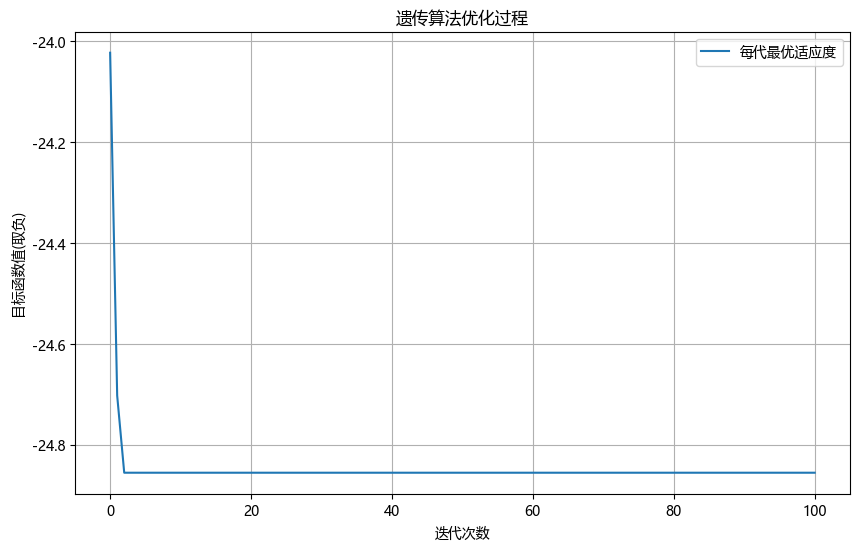

In [79]:
ga.plot_history()

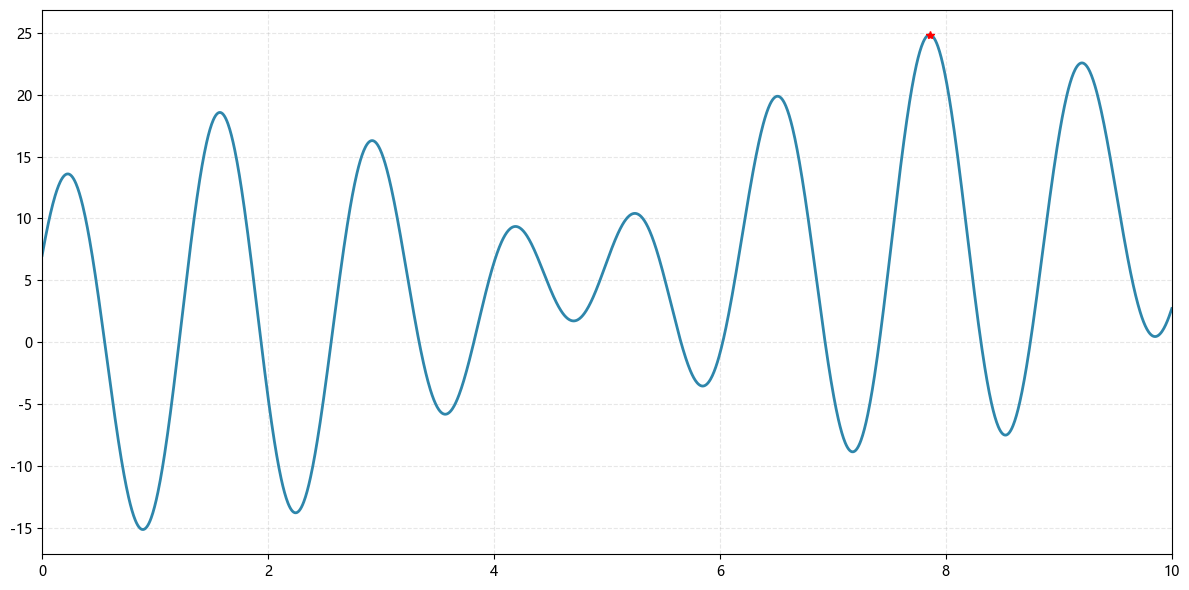

In [80]:
ga.plot_best_ind()